In [2]:
# Experiment 5 
# Writing a function lives_saved(threshold, prevalence, population_size)
'''
It computes extra positives caught, extra false positives generated, net lives saved.
loop over 100 thresholds and plot lives saved vs tests wasted.
find the threshold where lives_saved is maximized
'''

'\nIt computes extra positives caught, extra false positives generated, net lives saved.\nloop over 100 thresholds and plot lives saved vs tests wasted.\nfind the threshold where lives_saved is maximized\n'

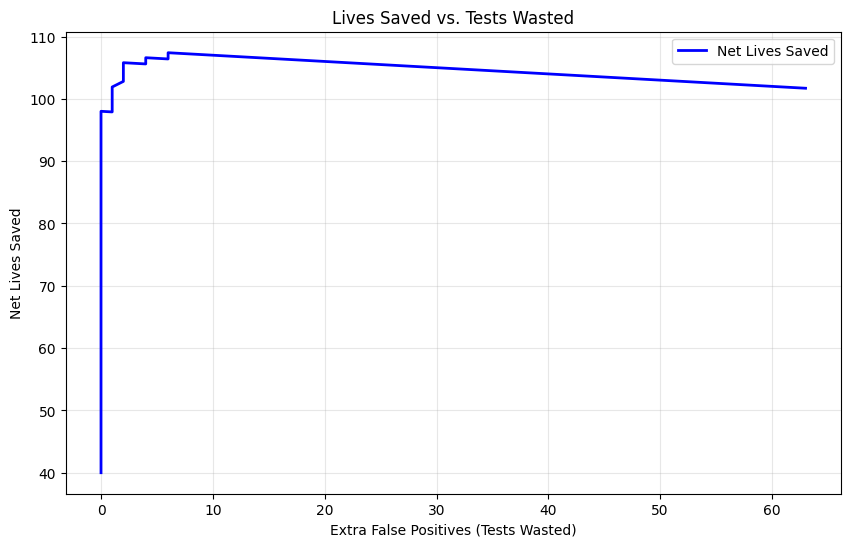

Optimal Threshold: 0.232
Maximum Lives Saved: 107.4
Extra True Positives: 108.0
Extra False Positives: 6.0


In [6]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_scores = model.predict_proba(X_test)[:, 1]

# Define the lives_saved function
def lives_saved(threshold, prevalence, population_size, y_true, y_scores):
    y_pred = (y_scores >= threshold).astype(int)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    baseline_tp = 0
    baseline_fp = 0
    extra_tp = tp - baseline_tp
    extra_fp = fp - baseline_fp
    cost_per_fp = 0.1  # Assume 10% of false positives lead to harm
    net_lives_saved = extra_tp - (extra_fp * cost_per_fp)
    return extra_tp, extra_fp, net_lives_saved

# Define parameters
prevalence = 0.01  # 1% of the population has the disease
population_size = 100000  # 100,000 people

# Generate 100 thresholds between 0 and 1
thresholds = np.linspace(0, 1, 100)  # Now this will work!

# Initialize lists to store results
extra_tps = []
extra_fps = []
net_lives_saved_list = []

# Loop over thresholds
for threshold in thresholds:
    extra_tp, extra_fp, net_lives_saved = lives_saved(
        threshold, prevalence, population_size, y_test, y_scores
    )
    extra_tps.append(extra_tp)
    extra_fps.append(extra_fp)
    net_lives_saved_list.append(net_lives_saved)

# Plot lives saved vs. tests wasted
plt.figure(figsize=(10, 6))
plt.plot(extra_fps, net_lives_saved_list, label='Net Lives Saved', color='blue', linewidth=2)
plt.xlabel('Extra False Positives (Tests Wasted)')
plt.ylabel('Net Lives Saved')
plt.title('Lives Saved vs. Tests Wasted')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Find the threshold that maximizes lives saved
best_threshold_idx = np.argmax(net_lives_saved_list)
best_threshold = thresholds[best_threshold_idx]
max_lives_saved = net_lives_saved_list[best_threshold_idx]

print(f"Optimal Threshold: {best_threshold:.3f}")
print(f"Maximum Lives Saved: {max_lives_saved:.1f}")
print(f"Extra True Positives: {extra_tps[best_threshold_idx]:.1f}")
print(f"Extra False Positives: {extra_fps[best_threshold_idx]:.1f}")
